In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.dates as mdates

In [2]:
climate_data = pd.read_csv('../../data_files/data/climate_api_data_2016_2024.csv')
fire_data = pd.read_csv('../../data_files/data/inpe_fire_counts_data_2016_2024.csv')
defor_data = pd.read_csv('../../data_files/data/deter_notification_data/treated_deter_deforestation_data_2016_2024.csv')

# Merge data
climate_data = climate_data.merge(fire_data[['date', 'fire_counts']], on='date', how='left')
climate_data = climate_data.merge(defor_data[['date', 'total_degradation']], on='date', how='left')
climate_data['fire_counts'] = climate_data['fire_counts'].fillna(0)
climate_data['total_degradation'] = climate_data['total_degradation'].fillna(0)

# Extract actual environmental variables
temp_actual = climate_data['temp_med'].dropna().values
humid_actual = climate_data['umid_med'].dropna().values
rain_actual = climate_data['precip_med'].dropna().values
fire_actual = climate_data['fire_counts'].values
defor_actual = climate_data['total_degradation'].values

print('Environmental Data Summary (Manaus, Brazil 2016-2024)')
print('='*60)
print(f"Temperature:  min={temp_actual.min():.1f}°C, max={temp_actual.max():.1f}°C, mean={temp_actual.mean():.1f}°C")
print(f"Humidity:     min={humid_actual.min():.1f}%, max={humid_actual.max():.1f}%, mean={humid_actual.mean():.1f}%")
print(f"Precipitation: min={rain_actual.min():.1f}mm, max={rain_actual.max():.1f}mm, mean={rain_actual.mean():.1f}mm")
print(f"Fire counts:  min={fire_actual.min():.0f}, max={fire_actual.max():.0f}, mean={fire_actual.mean():.1f}")
print(f"Deforestation: min={defor_actual.min():.2f}km², max={defor_actual.max():.2f}km², mean={defor_actual.mean():.2f}km²")
print('='*60)


Environmental Data Summary (Manaus, Brazil 2016-2024)
Temperature:  min=23.1°C, max=32.5°C, mean=26.7°C
Humidity:     min=46.6%, max=95.9%, mean=83.3%
Precipitation: min=0.0mm, max=71.2mm, mean=3.7mm
Fire counts:  min=0, max=169, mean=0.9
Deforestation: min=0.00km², max=8.34km², mean=0.02km²


In [3]:
# ============================================================================
# MODEL PARAMETERS
# ============================================================================

T_prime = 19.9
B_E = 200
p_ME = 0.9
p_ML = 0.25
p_MP = 0.75
tau_E = 1
tau_P = 1
c1 = 0.00554
c2 = -0.06737
D1 = 36.5
A = -0.03
B = 1.31
C = -4.4
b1 = 0.04
b2 = 0.09

DD = 105
Tmin = 14.5
R_L = 32.67

defor_max_effect = 0.30
defor_scale = 0.0001
fire_smoke_effect = 0.40
fire_habitat_effect = 0.20


In [4]:
# Critical temperatures for Plasmodium development
optimal_temp_plasm = 23.5
critical_max_temp_plasm = 29.8
#critical_min_temp_plasm = 14.5 # Tmin

# Critical temperatures for Anopheles development
optimal_temp_anop = 25 #26
critical_max_temp_anop = 34 #40
critical_min_temp_anop = 16 #10

In [5]:
def tau_L(Temp):
    """Larval development duration - vectorized"""
    Temp = np.asarray(Temp)
    denominator = c1 * Temp + c2
    result = np.where(denominator <= 0, np.inf, 1.0 / denominator)
    return result

def p_T(Temp, Umid, x0=58.0, k=0.25, floor=0.05):
    """Adult survival probability - vectorized
    
    x0 = 58: Midpoint of the sigmoid (humidity where p_U ≈ 0.5)
    k = 0.25: Transition slope
    floor = 0.05: Minimum survival (micro-habitats)

    NOTE: This should use umid_min (daily minimum), NOT umid_med.
    """
    Temp = np.asarray(Temp)
    Umid = np.asarray(Umid)
    
    # Calculate p_T_temp (temperature component)
    denominator = A * Temp**2 + B * Temp + C
    p_T_temp = np.where(denominator <= 0, 0.0, np.exp(-1 / denominator))
    
    # Calculate p_U (humidity component)
    p_U = floor + (1.0 - floor) / (1.0 + np.exp(-k * (Umid - x0)))
    
    return p_T_temp * p_U

def p_LT(Temp):
    """Larval survival probability - vectorized"""
    Temp = np.asarray(Temp)
    exponent = c1 * Temp + c2
    return np.exp(-exponent)

def p_LR(Rain, R_L):
    """Larval development probability due to rain - vectorized"""
    Rain = np.asarray(Rain)
    result = np.where((Rain < 0) | (Rain > R_L), 0.0,
                      (4 * p_ML / R_L**2) * Rain * (R_L - Rain))
    return result

def p_ER(Rain, R_L):
    """Egg development probability due to rain - vectorized"""
    Rain = np.asarray(Rain)
    result = np.where((Rain < 0) | (Rain > R_L), 0.0,
                      (4 * p_ME / R_L**2) * Rain * (R_L - Rain))
    return result

def p_PR(Rain, R_L):
    """Pupae development probability due to rain - vectorized"""
    Rain = np.asarray(Rain)
    result = np.where((Rain < 0) | (Rain > R_L), 0.0,
                      (4 * p_MP / R_L**2) * Rain * (R_L - Rain))
    return result

def tau_M(Temp):
    """Mosquito maturation time - vectorized"""
    Temp = np.asarray(Temp)
    result = np.where(Temp <= Tmin, np.inf, DD / (Temp - Tmin))
    return result

def mu(Temp, Umid, x0=58.0, k=0.25, floor=0.05):
    """Adult mosquito mortality rate - vectorized"""
    Temp = np.asarray(Temp)
    Umid = np.asarray(Umid)
    
    # Calculate p_T_val first
    denominator = A * Temp**2 + B * Temp + C
    p_T_temp = np.where(denominator <= 0, 0.0, np.exp(-1 / denominator))
    
    # Calculate p_U (humidity component)
    p_U = floor + (1.0 - floor) / (1.0 + np.exp(-k * (Umid - x0)))
    
    p_T_val = p_T_temp * p_U
    
    # Calculate mu
    mu_val = np.where(p_T_val <= 0, np.inf, -np.log(p_T_val))
    return mu_val

def a(Temp):
    """Biting rate - vectorized"""
    Temp = np.asarray(Temp)
    a_val = np.maximum(0, (Temp - T_prime) / D1)
    return a_val

def a_with_fire(Temp, fire_counts, fire_smoke_effect):
    """Biting rate with fire effect - vectorized"""
    Temp = np.asarray(Temp)
    fire_counts = np.asarray(fire_counts)
    
    base_rate = a(Temp)
    fire_intensity = np.minimum(fire_counts / 50.0, 1.0)
    smoke_reduction = fire_smoke_effect * fire_intensity
    return base_rate * (1 - smoke_reduction)

def b_rate(Rain, Temp, R_L):
    """Birth rate of adult mosquitoes - vectorized"""
    Rain = np.asarray(Rain)
    Temp = np.asarray(Temp)
    
    tau_L_curr = tau_L(Temp)
    
    # Calculate numerator components
    p_ER_val = p_ER(Rain, R_L)
    p_LR_val = p_LR(Rain, R_L)
    p_LT_val = p_LT(Temp)
    p_PR_val = p_PR(Rain, R_L)
    
    numerator = B_E * p_ER_val * p_LR_val * p_LT_val * p_PR_val
    denominator = tau_E + tau_L_curr + tau_P
    
    # Handle division by zero or infinite tau_L
    result = np.where((denominator <= 0) | (tau_L_curr == np.inf), 0.0, 
                      numerator / denominator)
    return result

def b_rate_with_environment(Rain, Temp, R_L, fire_counts, total_degradation):
    """Birth rate with environmental effects - vectorized"""
    Rain = np.asarray(Rain)
    Temp = np.asarray(Temp)
    fire_counts = np.asarray(fire_counts)
    total_degradation = np.asarray(total_degradation)
    
    base_rate = b_rate(Rain, Temp, R_L)
    
    defor_effect = np.minimum(total_degradation * defor_scale, defor_max_effect)
    fire_intensity = np.minimum(fire_counts / 50.0, 1.0)
    fire_habitat_destruction = fire_habitat_effect * fire_intensity
    
    net_effect = (1 + defor_effect) * (1 - fire_habitat_destruction)
    return base_rate * net_effect

def mu_with_fire(Temp, Umid, fire_counts, fire_habitat_effect):
    """Mortality rate with fire effect - vectorized"""
    Temp = np.asarray(Temp)
    Umid = np.asarray(Umid)
    fire_counts = np.asarray(fire_counts)
    
    base_mu = mu(Temp, Umid)
    fire_intensity = np.minimum(fire_counts / 50.0, 1.0)
    fire_mortality_increase = 0.15 * fire_intensity
    
    result = np.minimum(base_mu + fire_mortality_increase, 0.5)
    return result

print('Vectorized functions loaded successfully!')

Vectorized functions loaded successfully!


In [6]:
climate_data['date'] = pd.to_datetime(climate_data['date'])

# Use the actual temperature data from your climate dataset
date_range = climate_data['date'].dropna().values

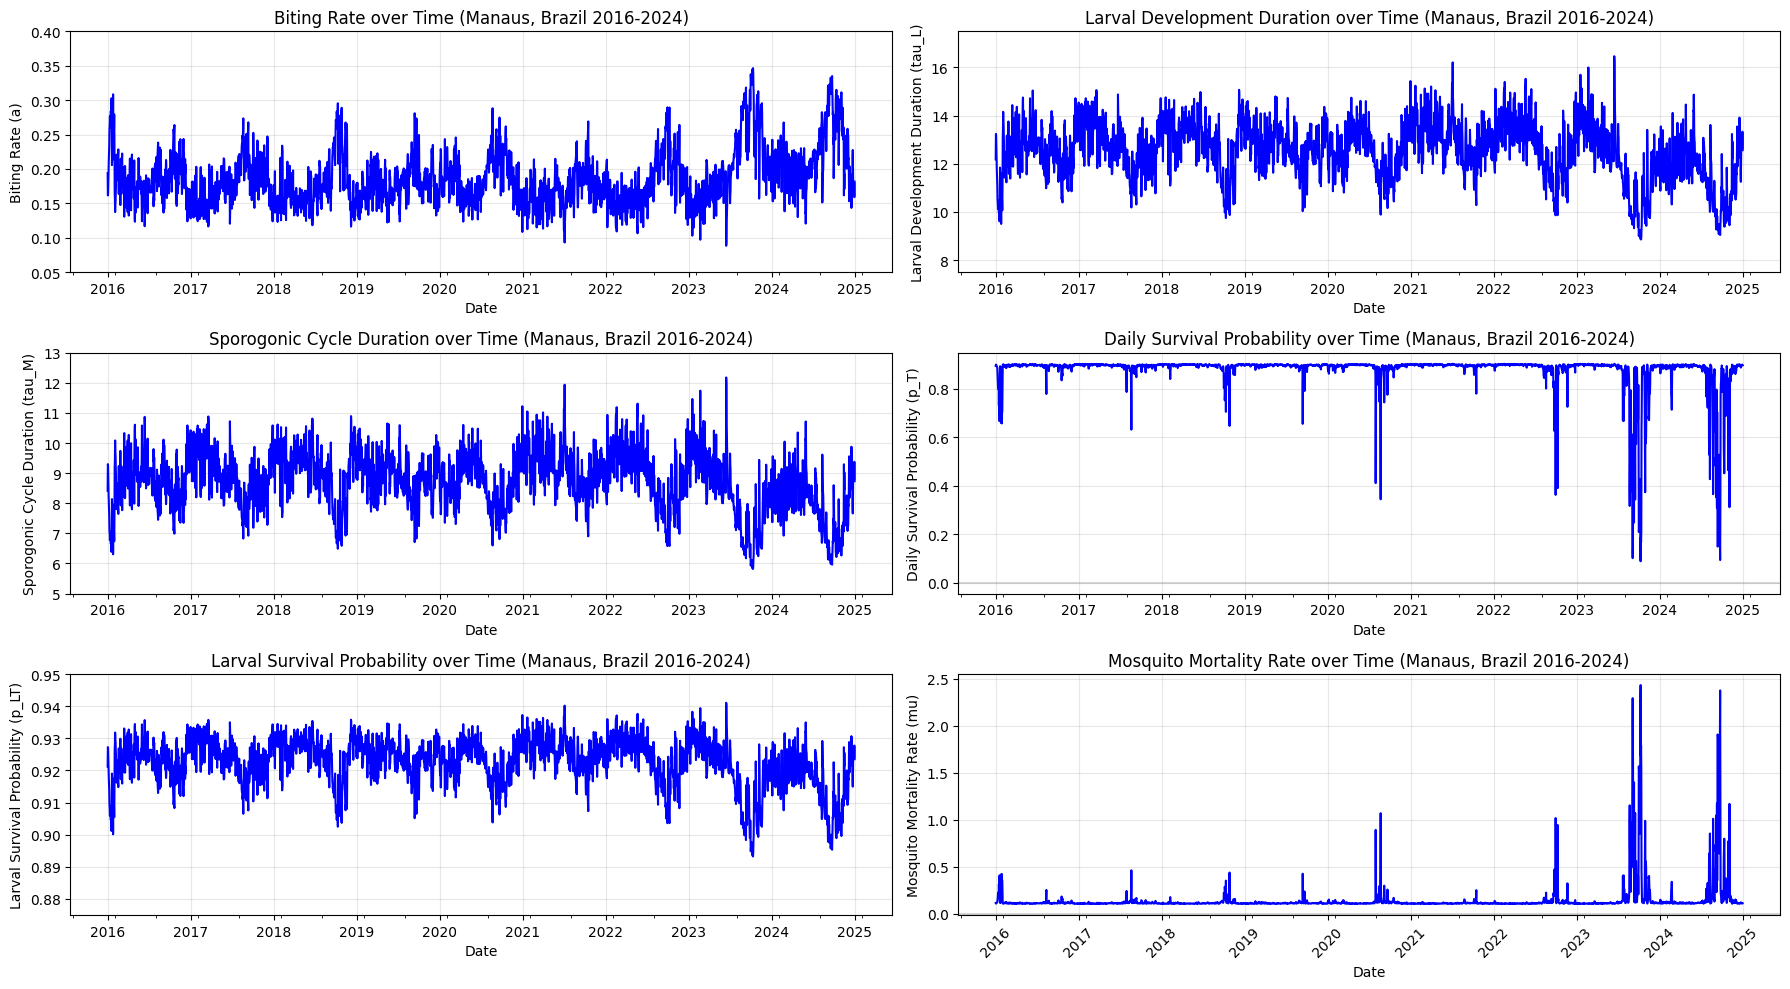

In [7]:
fig, axes = plt.subplots(3, 2, figsize=(18, 10))

# 1) Plot a vs time
a_over_time = a(temp_actual)

ax = axes[0, 0]
ax.plot(date_range, a_over_time, 'b-', linewidth=1.5)
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Date')
ax.set_ylabel('Biting Rate (a)')
ax.set_title('Biting Rate over Time (Manaus, Brazil 2016-2024)')
ax.grid(True, alpha=0.3)
ax.set_ylim(0.05, 0.4)  

# 2) Plot tau_L vs time
tau_L_over_time = tau_L(temp_actual)

ax = axes[0, 1]
ax.plot(date_range, tau_L_over_time, 'b-', linewidth=1.5)
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Date')
ax.set_ylabel('Larval Development Duration (tau_L)')
ax.set_title('Larval Development Duration over Time (Manaus, Brazil 2016-2024)')
ax.grid(True, alpha=0.3)
ax.set_ylim(7.5, 17.5)  

# 3) Plot tau_M vs time
tau_M_over_time = tau_M(temp_actual)

ax = axes[1, 0]
ax.plot(date_range, tau_M_over_time, 'b-', linewidth=1.5)
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Date')
ax.set_ylabel('Sporogonic Cycle Duration (tau_M)')
ax.set_title('Sporogonic Cycle Duration over Time (Manaus, Brazil 2016-2024)')
ax.grid(True, alpha=0.3)
ax.set_ylim(5.0, 13.0)  

# 4) Plot p_T vs time
p_T_over_time = p_T(temp_actual, humid_actual)

ax = axes[1,1]
ax.plot(date_range, p_T_over_time, 'b-', linewidth=1.5)
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Date')
ax.set_ylabel('Daily Survival Probability (p_T)')
ax.set_title('Daily Survival Probability over Time (Manaus, Brazil 2016-2024)')
ax.grid(True, alpha=0.3)
#ax.set_ylim(7.5, 17.5)  

# 5) Plot p_LT vs time
p_LT_over_time = p_LT(temp_actual)

ax = axes[2,0]
ax.plot(date_range, p_LT_over_time, 'b-', linewidth=1.5)
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Date')
ax.set_ylabel('Larval Survival Probability (p_LT)')
ax.set_title('Larval Survival Probability over Time (Manaus, Brazil 2016-2024)')
ax.grid(True, alpha=0.3)
ax.set_ylim(0.875, 0.95) 

# 6) Plot mu vs time
mu_over_time = mu(temp_actual, humid_actual)

ax = axes[2,1]
ax.plot(date_range, mu_over_time, 'b-', linewidth=1.5)
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Date')
ax.set_ylabel('Mosquito Mortality Rate (mu)')
ax.set_title('Mosquito Mortality Rate over Time (Manaus, Brazil 2016-2024)')
ax.grid(True, alpha=0.3)
#ax.set_ylim(7.5, 17.5) 

# Simplify x-axis for both subplots
for ax in axes.flatten():  # Use .flat to iterate over all subplots in 2D array
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=6))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
climate_data['date'] = pd.to_datetime(climate_data['date'])
climate_data_filtered = climate_data[climate_data['date'].between('2023-01-01', '2024-12-31')]
date_range = climate_data_filtered['date'].dropna().values

# Extract actual environmental variables
temp_actual = climate_data_filtered['temp_med'].dropna().values
humid_actual = climate_data_filtered['umid_med'].dropna().values
rain_actual = climate_data_filtered['precip_med'].dropna().values
fire_actual = climate_data_filtered['fire_counts'].values
defor_actual = climate_data_filtered['total_degradation'].values

(array([19417., 19601., 19783., 19967.]),
 [Text(19417.0, 0, 'Mar 2023'),
  Text(19601.0, 0, 'Sep 2023'),
  Text(19783.0, 0, 'Mar 2024'),
  Text(19967.0, 0, 'Sep 2024')])

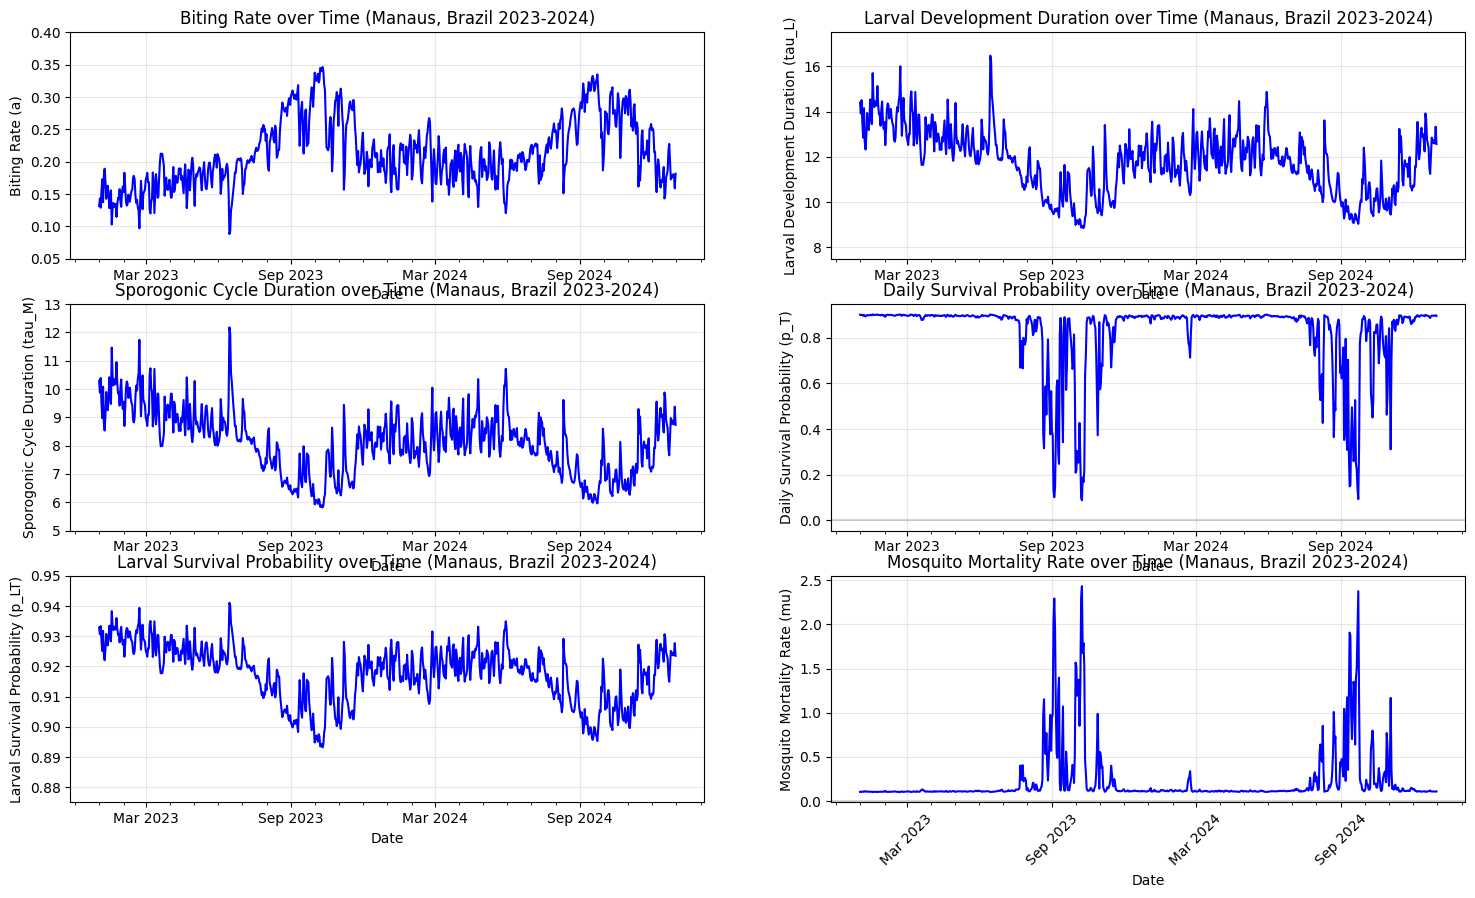

In [9]:
fig, axes = plt.subplots(3, 2, figsize=(18, 10))

# 1) Plot a vs time
a_over_time = a(temp_actual)

ax = axes[0, 0]
ax.plot(date_range, a_over_time, 'b-', linewidth=1.5)
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Date')
ax.set_ylabel('Biting Rate (a)')
ax.set_title('Biting Rate over Time (Manaus, Brazil 2023-2024)')
ax.grid(True, alpha=0.3)
ax.set_ylim(0.05, 0.4)  

# 2) Plot tau_L vs time
tau_L_over_time = tau_L(temp_actual)

ax = axes[0, 1]
ax.plot(date_range, tau_L_over_time, 'b-', linewidth=1.5)
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Date')
ax.set_ylabel('Larval Development Duration (tau_L)')
ax.set_title('Larval Development Duration over Time (Manaus, Brazil 2023-2024)')
ax.grid(True, alpha=0.3)
ax.set_ylim(7.5, 17.5)  

# 3) Plot tau_M vs time
tau_M_over_time = tau_M(temp_actual)

ax = axes[1, 0]
ax.plot(date_range, tau_M_over_time, 'b-', linewidth=1.5)
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Date')
ax.set_ylabel('Sporogonic Cycle Duration (tau_M)')
ax.set_title('Sporogonic Cycle Duration over Time (Manaus, Brazil 2023-2024)')
ax.grid(True, alpha=0.3)
ax.set_ylim(5.0, 13.0)  

# 4) Plot p_T vs time
p_T_over_time = p_T(temp_actual, humid_actual)

ax = axes[1,1]
ax.plot(date_range, p_T_over_time, 'b-', linewidth=1.5)
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Date')
ax.set_ylabel('Daily Survival Probability (p_T)')
ax.set_title('Daily Survival Probability over Time (Manaus, Brazil 2023-2024)')
ax.grid(True, alpha=0.3)
#ax.set_ylim(7.5, 17.5)  

# 5) Plot p_LT vs time
p_LT_over_time = p_LT(temp_actual)

ax = axes[2,0]
ax.plot(date_range, p_LT_over_time, 'b-', linewidth=1.5)
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Date')
ax.set_ylabel('Larval Survival Probability (p_LT)')
ax.set_title('Larval Survival Probability over Time (Manaus, Brazil 2023-2024)')
ax.grid(True, alpha=0.3)
ax.set_ylim(0.875, 0.95) 

# 6) Plot mu vs time
mu_over_time = mu(temp_actual, humid_actual)

ax = axes[2,1]
ax.plot(date_range, mu_over_time, 'b-', linewidth=1.5)
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Date')
ax.set_ylabel('Mosquito Mortality Rate (mu)')
ax.set_title('Mosquito Mortality Rate over Time (Manaus, Brazil 2023-2024)')
ax.grid(True, alpha=0.3)
#ax.set_ylim(7.5, 17.5) 

# Simplify x-axis for both subplots
for ax in axes.flat:
    # Set major ticks every 6 months with year
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))  # "Jan 2023"
    
    # Set minor ticks every month without labels
    ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=1))
    
plt.xticks(rotation=45)

In [10]:
climate_data['date'] = pd.to_datetime(climate_data['date'])
climate_data_filtered = climate_data[climate_data['date'].between('2023-07-01', '2023-12-31')]
date_range = climate_data_filtered['date'].dropna().values

# Extract actual environmental variables
temp_actual = climate_data_filtered['temp_med'].dropna().values
humid_actual = climate_data_filtered['umid_med'].dropna().values
rain_actual = climate_data_filtered['precip_med'].dropna().values
fire_actual = climate_data_filtered['fire_counts'].values
defor_actual = climate_data_filtered['total_degradation'].values

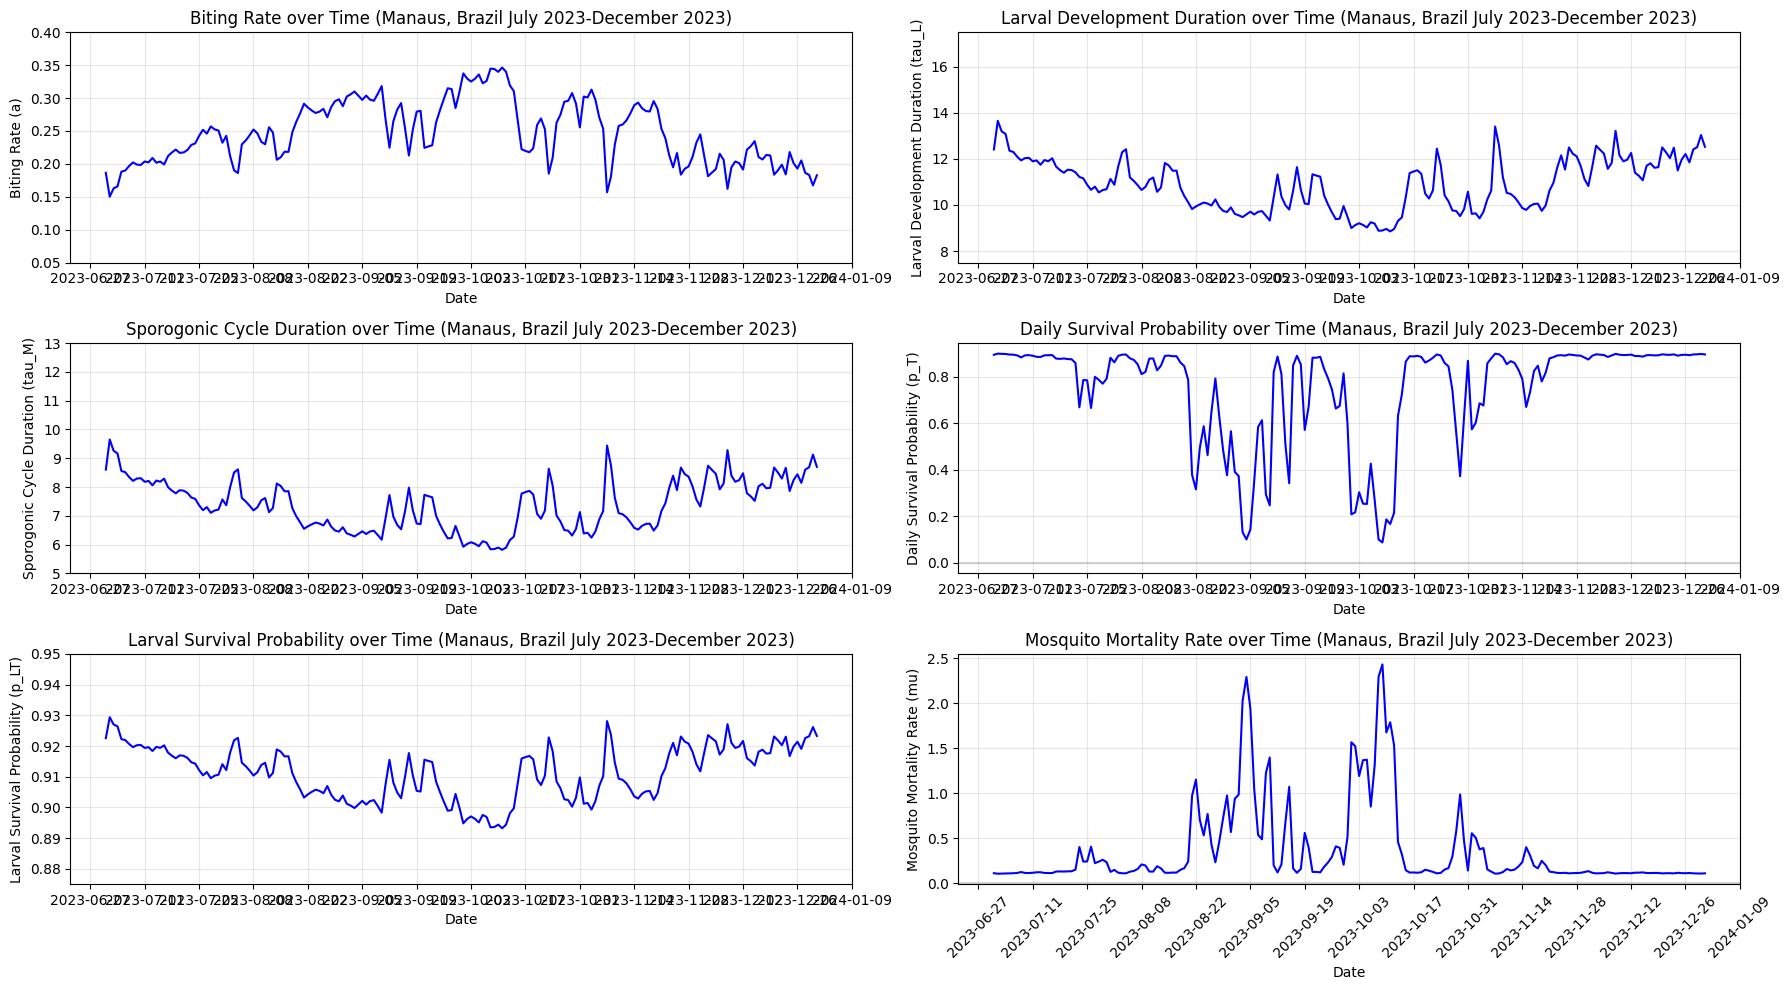

In [11]:
fig, axes = plt.subplots(3, 2, figsize=(18, 10))

# 1) Plot a vs time
a_over_time = a(temp_actual)

ax = axes[0, 0]
ax.plot(date_range, a_over_time, 'b-', linewidth=1.5)
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Date')
ax.set_ylabel('Biting Rate (a)')
ax.set_title('Biting Rate over Time (Manaus, Brazil July 2023-December 2023)')
ax.grid(True, alpha=0.3)
ax.set_ylim(0.05, 0.4)  

# 2) Plot tau_L vs time
tau_L_over_time = tau_L(temp_actual)

ax = axes[0, 1]
ax.plot(date_range, tau_L_over_time, 'b-', linewidth=1.5)
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Date')
ax.set_ylabel('Larval Development Duration (tau_L)')
ax.set_title('Larval Development Duration over Time (Manaus, Brazil July 2023-December 2023)')
ax.grid(True, alpha=0.3)
ax.set_ylim(7.5, 17.5)  

# 3) Plot tau_M vs time
tau_M_over_time = tau_M(temp_actual)

ax = axes[1, 0]
ax.plot(date_range, tau_M_over_time, 'b-', linewidth=1.5)
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Date')
ax.set_ylabel('Sporogonic Cycle Duration (tau_M)')
ax.set_title('Sporogonic Cycle Duration over Time (Manaus, Brazil July 2023-December 2023)')
ax.grid(True, alpha=0.3)
ax.set_ylim(5.0, 13.0)  

# 4) Plot p_T vs time
p_T_over_time = p_T(temp_actual, humid_actual)

ax = axes[1,1]
ax.plot(date_range, p_T_over_time, 'b-', linewidth=1.5)
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Date')
ax.set_ylabel('Daily Survival Probability (p_T)')
ax.set_title('Daily Survival Probability over Time (Manaus, Brazil July 2023-December 2023)')
ax.grid(True, alpha=0.3)
#ax.set_ylim(7.5, 17.5)  

# 5) Plot p_LT vs time
p_LT_over_time = p_LT(temp_actual)

ax = axes[2,0]
ax.plot(date_range, p_LT_over_time, 'b-', linewidth=1.5)
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Date')
ax.set_ylabel('Larval Survival Probability (p_LT)')
ax.set_title('Larval Survival Probability over Time (Manaus, Brazil July 2023-December 2023)')
ax.grid(True, alpha=0.3)
ax.set_ylim(0.875, 0.95) 

# 6) Plot mu vs time
mu_over_time = mu(temp_actual, humid_actual)

ax = axes[2,1]
ax.plot(date_range, mu_over_time, 'b-', linewidth=1.5)
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Date')
ax.set_ylabel('Mosquito Mortality Rate (mu)')
ax.set_title('Mosquito Mortality Rate over Time (Manaus, Brazil July 2023-December 2023)')
ax.grid(True, alpha=0.3)
#ax.set_ylim(7.5, 17.5) 

# Simplify x-axis for both subplots
import matplotlib.dates as mdates
for ax in axes.flatten():
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))  # Every 2 weeks
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
climate_data['date'] = pd.to_datetime(climate_data['date'])
climate_data_filtered = climate_data[climate_data['date'].between('2023-08-01', '2023-10-31')]
date_range = climate_data_filtered['date'].dropna().values

# Extract actual environmental variables
temp_actual = climate_data_filtered['temp_med'].dropna().values
humid_actual = climate_data_filtered['umid_med'].dropna().values
rain_actual = climate_data_filtered['precip_med'].dropna().values
fire_actual = climate_data_filtered['fire_counts'].values
defor_actual = climate_data_filtered['total_degradation'].values

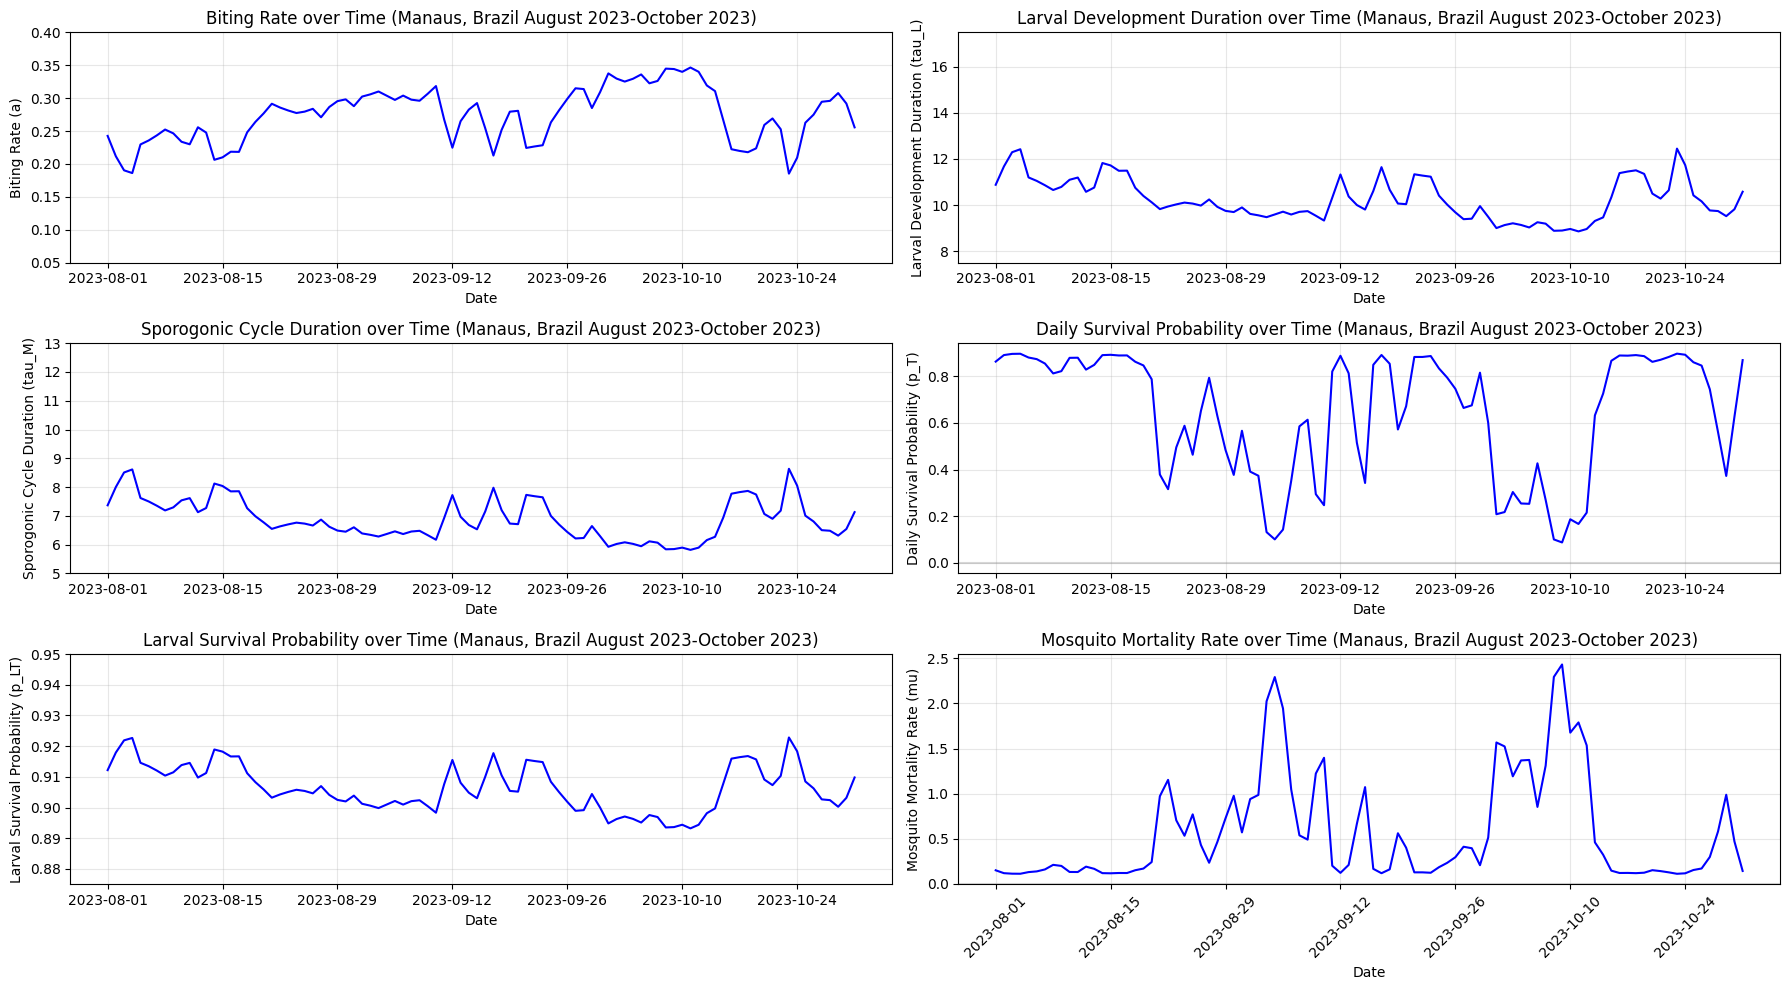

In [13]:
fig, axes = plt.subplots(3, 2, figsize=(18, 10))

# 1) Plot a vs time
a_over_time = a(temp_actual)

ax = axes[0, 0]
ax.plot(date_range, a_over_time, 'b-', linewidth=1.5)
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Date')
ax.set_ylabel('Biting Rate (a)')
ax.set_title('Biting Rate over Time (Manaus, Brazil August 2023-October 2023)')
ax.grid(True, alpha=0.3)
ax.set_ylim(0.05, 0.4)  

# 2) Plot tau_L vs time
tau_L_over_time = tau_L(temp_actual)

ax = axes[0, 1]
ax.plot(date_range, tau_L_over_time, 'b-', linewidth=1.5)
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Date')
ax.set_ylabel('Larval Development Duration (tau_L)')
ax.set_title('Larval Development Duration over Time (Manaus, Brazil August 2023-October 2023)')
ax.grid(True, alpha=0.3)
ax.set_ylim(7.5, 17.5)  

# 3) Plot tau_M vs time
tau_M_over_time = tau_M(temp_actual)

ax = axes[1, 0]
ax.plot(date_range, tau_M_over_time, 'b-', linewidth=1.5)
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Date')
ax.set_ylabel('Sporogonic Cycle Duration (tau_M)')
ax.set_title('Sporogonic Cycle Duration over Time (Manaus, Brazil August 2023-October 2023)')
ax.grid(True, alpha=0.3)
ax.set_ylim(5.0, 13.0)  

# 4) Plot p_T vs time
p_T_over_time = p_T(temp_actual, humid_actual)

ax = axes[1,1]
ax.plot(date_range, p_T_over_time, 'b-', linewidth=1.5)
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Date')
ax.set_ylabel('Daily Survival Probability (p_T)')
ax.set_title('Daily Survival Probability over Time (Manaus, Brazil August 2023-October 2023)')
ax.grid(True, alpha=0.3)
#ax.set_ylim(7.5, 17.5)  

# 5) Plot p_LT vs time
p_LT_over_time = p_LT(temp_actual)

ax = axes[2,0]
ax.plot(date_range, p_LT_over_time, 'b-', linewidth=1.5)
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Date')
ax.set_ylabel('Larval Survival Probability (p_LT)')
ax.set_title('Larval Survival Probability over Time (Manaus, Brazil August 2023-October 2023)')
ax.grid(True, alpha=0.3)
ax.set_ylim(0.875, 0.95) 

# 6) Plot mu vs time
mu_over_time = mu(temp_actual, humid_actual)

ax = axes[2,1]
ax.plot(date_range, mu_over_time, 'b-', linewidth=1.5)
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Date')
ax.set_ylabel('Mosquito Mortality Rate (mu)')
ax.set_title('Mosquito Mortality Rate over Time (Manaus, Brazil August 2023-October 2023)')
ax.grid(True, alpha=0.3)
#ax.set_ylim(7.5, 17.5) 

# Simplify x-axis for both subplots
import matplotlib.dates as mdates
for ax in axes.flatten():
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))  # Every 2 weeks
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()